## Example 3 (One-Sample T-Test, Two-Tailed, 95% Confidence Interval)

In the population, the average **IQ is 100**. A team of researchers wants to test a new medication to see if it has either a **positive or negative** effect on intelligence, or **no effect at all**. A sample of **30 participants** who have taken the medication has a mean of **140**, with a standard deviation of **20**. Did the medication affect intelligence? (**CI = 95%**)

**Given:**
- $\mu = 100$ (population mean IQ)
- $n = 30$ (sample size)
- $\bar{x} = 140$ (sample mean)
- $S = 20$ (sample std)
- $CI = 95\%$

Because the researchers are checking for **either** a positive **or** a negative effect (not specifically one direction), this is a **two-tailed test**.

### Step 1 - State the Null and Alternate Hypothesis

$$H_0: \mu = 100$$
$$H_1: \mu \neq 100 \quad \text{(two-tailed test)}$$

- $H_0$ (Null Hypothesis) — the medication has **no effect** on IQ; the sample mean of 140 is just due to random sampling variation.
- $H_1$ (Alternate Hypothesis) — the medication **does** affect IQ (could be higher or lower), so we test both directions at once.

### Step 2 - Significance Value

$$CI = 95\% = 0.95$$
$$\alpha = 1 - CI = 1 - 0.95 = 0.05$$

$\alpha$ is the probability of a **Type I error** — rejecting $H_0$ when it's actually true — that we're willing to accept. We fix this *before* looking at the sample data. Because this is two-tailed, this risk is split evenly between both tails of the distribution:

$$\dfrac{\alpha}{2} = \dfrac{0.05}{2} = 0.025 \text{ on each side}$$

### Step 3 - Degrees of Freedom

$$df = n - 1 = 30 - 1 = 29$$

We use the **t-distribution** (not the z-distribution) here because the population standard deviation $\sigma$ is unknown — we only have the sample standard deviation $S = 20$. Estimating the spread from the sample itself introduces extra uncertainty, so the t-distribution has fatter tails than the normal distribution, and `df` controls exactly how fat. The `-1` reflects that one degree of freedom is "used up" estimating the sample mean $\bar{x}$ itself.

In [1]:
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt

### Step 4 - Decision Boundary

Look up the t-table at **df = 29**, two-tailed $\alpha = 0.05$ (i.e. 0.025 in each tail):

$$t_{critical} = \pm 2.045$$

The region between $-2.045$ and $+2.045$ is the **acceptance region** (fail to reject $H_0$). Anything beyond that, in either tail, is the **rejection region** (reject $H_0$).

**Decision rule:** If $t_{test} < -2.045$ or $t_{test} > 2.045$, reject the null hypothesis.

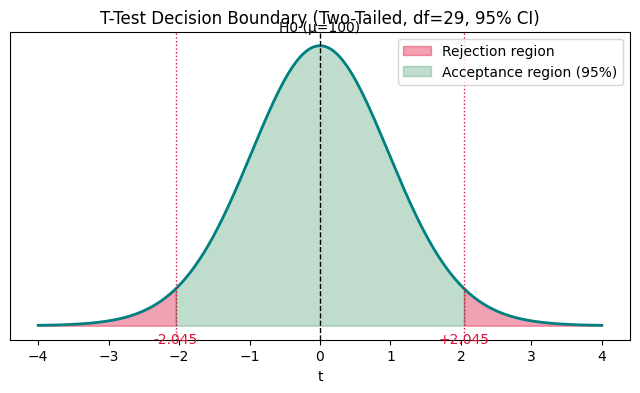

In [2]:
df = 29
alpha = 0.05

t_crit = st.t.ppf(1 - alpha / 2, df)   # 2.045

x = np.linspace(-4, 4, 500)
y = st.t.pdf(x, df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, color="teal", linewidth=2)

# rejection regions - both tails
x_left = np.linspace(-4, -t_crit, 100)
x_right = np.linspace(t_crit, 4, 100)
ax.fill_between(x_left, st.t.pdf(x_left, df), color="crimson", alpha=0.4, label="Rejection region")
ax.fill_between(x_right, st.t.pdf(x_right, df), color="crimson", alpha=0.4)

# acceptance region
x_mid = np.linspace(-t_crit, t_crit, 200)
ax.fill_between(x_mid, st.t.pdf(x_mid, df), color="seagreen", alpha=0.3, label="Acceptance region (95%)")

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.text(0, max(y) * 1.05, "H0 (μ=100)", ha="center")
ax.axvline(-t_crit, color="crimson", linestyle=":", linewidth=1)
ax.axvline(t_crit, color="crimson", linestyle=":", linewidth=1)
ax.text(-t_crit, -0.01, f"-{t_crit:.3f}", ha="center", va="top", color="crimson")
ax.text(t_crit, -0.01, f"+{t_crit:.3f}", ha="center", va="top", color="crimson")

ax.legend()
ax.set_yticks([])
ax.set_xlabel("t")
ax.set_title(f"T-Test Decision Boundary (Two-Tailed, df={df}, 95% CI)")
plt.show()

### Step 5 - Calculate the T-Test Statistic

$$t_{test} = \dfrac{\bar{x} - \mu}{\dfrac{S}{\sqrt{n}}} = \dfrac{140 - 100}{\dfrac{20}{\sqrt{30}}} = \dfrac{40}{3.65} \approx 10.96$$

In [3]:
x_bar = 140
mu = 100
S = 20
n = 30
alpha = 0.05
df = n - 1

t_critical = st.t.ppf(1 - alpha / 2, df)   # two-tailed -> 2.045
t_test = (x_bar - mu) / (S / np.sqrt(n))

print("df:", df)
print("t_critical: +-", round(t_critical, 4))
print("t_test:", round(t_test, 4))

df: 29
t_critical: +- 2.0452
t_test: 10.9545


### Step 6 - Conclusion

**Decision rule:** If $t_{test}$ is less than $-2.045$ or greater than $+2.045$, reject the null hypothesis.

$$t_{test} (10.96) > t_{critical} (2.045)$$

This is true — $t_{test}$ falls far inside the rejection region → **reject $H_0$, accept $H_1$**.

**Conclusion:** At the 95% confidence level, there is enough evidence to say the medication had a statistically significant effect on intelligence — the jump from an average IQ of 100 to a sample mean of 140 is extremely unlikely to be random sampling noise.

In [4]:
if abs(t_test) > t_critical:
    print("Reject H0 -> H1 is right (medication DOES affect intelligence)")
else:
    print("Fail to reject H0 -> H0 holds (no significant evidence of an effect)")

Reject H0 -> H1 is right (medication DOES affect intelligence)


### Plotting the actual t_test value

The earlier plot only showed the critical boundaries ($\pm 2.045$). Here we mark the **actual computed value, $t_{test} \approx 10.96$**, on the same curve — it lands so far into the tail that it's off the visible range of a standard plot, which visually drives home just how strong this result is.

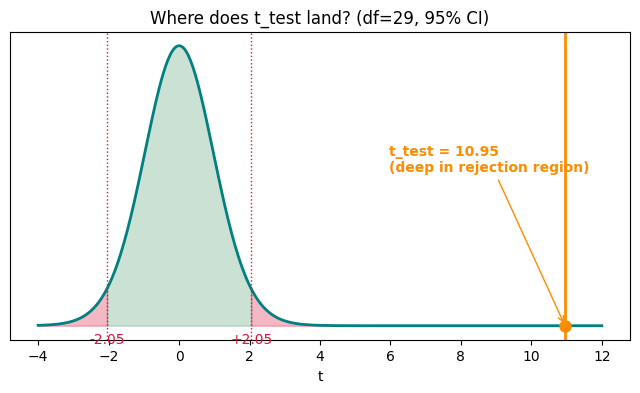

In [5]:
x = np.linspace(-4, 12, 500)
y = st.t.pdf(x, df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, color="teal", linewidth=2)

# rejection regions
x_left = np.linspace(-4, -t_critical, 100)
x_right = np.linspace(t_critical, 12, 100)
ax.fill_between(x_left, st.t.pdf(x_left, df), color="crimson", alpha=0.3)
ax.fill_between(x_right, st.t.pdf(x_right, df), color="crimson", alpha=0.3)

# acceptance region
x_mid = np.linspace(-t_critical, t_critical, 200)
ax.fill_between(x_mid, st.t.pdf(x_mid, df), color="seagreen", alpha=0.25)

# critical boundaries
ax.axvline(-t_critical, color="crimson", linestyle=":", linewidth=1)
ax.axvline(t_critical, color="crimson", linestyle=":", linewidth=1)
ax.text(-t_critical, -0.01, f"-{t_critical:.2f}", ha="center", va="top", color="crimson")
ax.text(t_critical, -0.01, f"+{t_critical:.2f}", ha="center", va="top", color="crimson")

# actual test statistic
ax.axvline(t_test, color="darkorange", linewidth=2)
ax.plot(t_test, st.t.pdf(t_test, df), "o", color="darkorange", markersize=8, zorder=5)
ax.annotate(f"t_test = {t_test:.2f}\n(deep in rejection region)",
            xy=(t_test, st.t.pdf(t_test, df)),
            xytext=(t_test - 5, max(y) * 0.55),
            arrowprops=dict(arrowstyle="->", color="darkorange"),
            color="darkorange", fontweight="bold")

ax.set_yticks([])
ax.set_xlabel("t")
ax.set_title("Where does t_test land? (df=29, 95% CI)")
plt.show()

---

## FAQ

**1. Why is this a t-test and not a z-test?**

The sample size is $n = 30$ and, more importantly, we're only given the **sample** standard deviation ($S = 20$), not the true population standard deviation $\sigma$. Whenever $\sigma$ is unknown, we must estimate spread from the sample, which adds uncertainty — the t-distribution (with its fatter tails, controlled by `df`) accounts for that. If the population $\sigma$ were known, we'd use a z-test instead, even at $n=30$.

**2. Why two-tailed instead of one-tailed?**

The question explicitly asks whether the medication has "either a positive or negative effect... or no effect at all." Since we care about a deviation in **either direction**, the rejection region must be split across **both** tails of the distribution ($\alpha/2$ each), giving $H_1: \mu \neq 100$. If the question instead asked "does the medication **increase** IQ," that would be one-tailed with $H_1: \mu > 100$.

**3. Why is $t_{test}$ so much larger than $t_{critical}$ here? What does the "40-point jump" mean?**

**The "40-point jump" is just the raw, unscaled gap in the formula's numerator:**

$$\bar{x} - \mu = 140 - 100 = 40$$

It's the plain difference between what we *observed* (sample mean IQ = 140) and what $H_0$ *claims* (population mean IQ = 100), measured in ordinary IQ points — before it gets divided by anything or turned into a standardized score.

**Step A — is 40 points a lot, for one person?** On its own, "40 points" is hard to judge — it depends on how much IQ scores naturally bounce around. The sample's spread is $S = 20$, so $40 / 20 = 2$: the gap equals **2 individual standard deviations**. For a single person, landing 2 standard deviations from the mean is somewhat unusual but not extraordinary.

**Step B — but we're not looking at one person, we're looking at the *average* of 30 people.** Averages are far more stable than individuals — random ups and downs across 30 different people mostly cancel out. The formula captures this by dividing by the **standard error of the mean** instead of the raw standard deviation:

$$SE = \dfrac{S}{\sqrt{n}} = \dfrac{20}{\sqrt{30}} \approx 3.65$$

Notice $SE \approx 3.65$ is roughly **5.5× smaller** than $S = 20$ — that shrinkage is exactly the benefit of averaging over 30 samples instead of looking at just 1.

**Step C — put the same 40-point gap over this much smaller yardstick:**

$$t_{test} = \dfrac{\bar{x}-\mu}{SE} = \dfrac{40}{3.65} \approx 10.96$$

So the *same* 40-point gap that was "only" 2 standard deviations at the individual level becomes **~11 standard errors** at the sample-mean level — because the yardstick used to judge it (SE) is so much finer than the yardstick for individuals (S).

**Intuition:** one person scoring 40 points above average is mildly surprising. But the *average* of 30 randomly chosen people scoring 40 points above the population average — with essentially no overlap in who's selected — is almost never going to happen just by chance. That's the whole point of dividing by $SE$ instead of $S$: it measures the gap in units of "how much sampling wobble we'd realistically expect for a mean of 30 people," not "how much any one person's score can wobble."

**Why this makes $t_{test} \gg t_{critical}$:** $t_{critical} \approx 2.045$ represents "about 2 standard errors" — the largest wobble we'd tolerate as plausibly due to chance at 95% confidence. Our actual result is **~11 standard errors** out — more than 5× further than the threshold — so it isn't a borderline call at all; it's a result that's essentially impossible to get under $H_0$ by random sampling alone.

**4. What does "reject $H_0$" actually tell us, and what doesn't it tell us?**

It tells us the difference is **statistically significant** — i.e., very unlikely to be random noise. It does **not** by itself prove the medication *causes* the IQ change (that depends on the study design, e.g. whether there was a control group, randomization, blinding, etc.), and it doesn't tell us anything about whether a 40-point jump is *practically* meaningful — that's a separate question from statistical significance.

**5. How would the conclusion change with an 80% confidence interval instead of 95%?**

A lower CI (80%) means a larger $\alpha = 0.20$, split into $\alpha/2 = 0.10$ per tail, which produces a **smaller** $|t_{critical}|$ (the acceptance region shrinks). Since our $t_{test} \approx 10.96$ is already far beyond the 95% CI's critical value, it would just as easily fall in the rejection region under an 80% CI — the conclusion (reject $H_0$) doesn't change, but the *margin* by which we reject does. See the companion notebook for the worked 80% CI version of this same problem.